# R(2) normal/opposite-parity peak ratio versus X/Z polarization admixture

This notebook scans a small amount of Z polarization admixed into X polarization and plots how the normal- and opposite-parity peak heights change.

The polarization is parameterized by a **Z intensity fraction**

```text
f_Z = |E_Z|^2 / (|E_X|^2 + |E_Z|^2)
```

and the normalized polarization vector is

```text
epsilon = sqrt(1 - f_Z) X + sqrt(f_Z) Z
```

so the total optical power is held fixed while the polarization composition changes.

Notes:

- `f_Z = 0` is pure X.
- `f_Z = 0.01` means 1% of the electric-field intensity is in Z, but the field amplitude ratio is `E_Z/E_X ≈ 0.1005`.
- Each distinct `f_Z` rebuilds the coupling matrices/OBE system, because the polarization vector changes the coupling graph and matrix elements.

In [1]:
from __future__ import annotations

import inspect
import time
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.constants as cst
import scipy.signal as signal
import sympy as smp

from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions
from centrex_tlf.couplings.polarization import Polarization
from centrex_tlf.lindblad.parameters import LindbladParameters
from centrex_tlf.lindblad.plan_static import prepare_lindblad_problem
from centrex_tlf.utils import population
from centrex_tlf.utils.rabi import (
    power_to_intensity_rectangular_beam,
    power_to_rabi_rectangular_beam,
)

plt.rcParams.update({"font.size": 14})

GAMMA = getattr(hamiltonian, "Γ")

## Configuration

In [2]:
transition = transitions.R2_F1_7o2_F3

# Use the field relevant to the NLTL fit by default. Set back to 200.0 V/cm
# if you want the same field as the original opposite-parity retention notebook.
E_FIELD_Z_V_CM = 171.6
E_FIELD = np.array([0.0, 0.0, E_FIELD_Z_V_CM])
B_FIELD = np.array([0.0, 0.0, 1e-5])

POWER_MW = 60.0
POWER_W = POWER_MW * 1e-3

BEAM_WX = 0.02
BEAM_WY = 0.02
VELOCITY = 184.0
INTERACTION_LENGTH = 0.02
T_END = INTERACTION_LENGTH / VELOCITY

INITIAL_F1 = 5 / 2
INITIAL_F = 2
INITIAL_MF = 0

# Same weighted initial F=3 population used in the recent notebooks.
INITIAL_POPULATION_SELECTORS = [
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F, mF=INITIAL_MF),
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F + 1, mF=-1),
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F + 1, mF=0),
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F + 1, mF=+1),
]
INITIAL_POPULATION_WEIGHTS = np.array([2 / 3, 1 / 9, 1 / 9, 1 / 9], dtype=float)

# Fine near zero, because a small Z fraction can already be a meaningful field-amplitude admixture.
Z_INTENSITY_FRACTIONS = np.array(
    [
        0.0,
        1e-4,
        3e-4,
        1e-3,
        3e-3,
        1e-2,
        2e-2,
        5e-2,
        1e-1,
        2e-1,
    ],
    dtype=float,
)

# Local peak search window settings.
NORMAL_PEAK_CENTER_FALLBACK_MHZ = 0.0
OPPOSITE_PEAK_CENTER_FALLBACK_MHZ = 25.0
PEAK_WINDOW_MHZ = 6.0
PEAK_DETUNING_STEP_MHZ = 0.5

SCAN_SAVEAT = np.linspace(0.0, T_END, 801)
SCAN_THREADS = None

FIT_REL_TOL = 1e-7
FIT_ABS_TOL = 1e-9

RABI_PARAMETER_NAME = "rabi"
DETUNING_PARAMETER_NAME = "detuning"

OPTICAL_FREQUENCY_HZ = 1.1e15
OPTICAL_WAVELENGTH_M = cst.c / OPTICAL_FREQUENCY_HZ

config = {
    "transition": transition.name,
    "E_field_V_per_cm": E_FIELD.tolist(),
    "power_mW": POWER_MW,
    "beam_cm_by_cm": (BEAM_WX * 100, BEAM_WY * 100),
    "intensity_mW_per_cm2": power_to_intensity_rectangular_beam(POWER_W, BEAM_WX, BEAM_WY) * 0.1,
    "velocity_m_per_s": VELOCITY,
    "interaction_time_us": T_END * 1e6,
    "z_intensity_fractions": Z_INTENSITY_FRACTIONS.tolist(),
}
config

{'transition': "R(2) F1'=7/2 F'=3",
 'E_field_V_per_cm': [0.0, 0.0, 171.6],
 'power_mW': 60.0,
 'beam_cm_by_cm': (2.0, 2.0),
 'intensity_mW_per_cm2': 15.0,
 'velocity_m_per_s': 184.0,
 'interaction_time_us': 108.69565217391305,
 'z_intensity_fractions': [0.0,
  0.0001,
  0.0003,
  0.001,
  0.003,
  0.01,
  0.02,
  0.05,
  0.1,
  0.2]}

## Normalized X/Z polarization

In [3]:
def xz_polarization(z_intensity_fraction: float) -> Polarization:
    # Return normalized epsilon = sqrt(1-fz) X + sqrt(fz) Z.
    fz = float(z_intensity_fraction)
    if fz < 0 or fz > 1:
        raise ValueError(f"z_intensity_fraction must be in [0, 1], got {fz}")

    ex = np.sqrt(1.0 - fz)
    ez = np.sqrt(fz)
    vector = np.array([ex, 0.0, ez], dtype=np.complex128)

    # Use a simple name to avoid huge symbol names. The actual vector is stored
    # in the TransitionSelector and coupling matrices.
    return Polarization(vector=vector, name=f"XZ{fz:.6g}")


def z_fraction_summary(fz_values: np.ndarray) -> pd.DataFrame:
    rows = []
    for fz in fz_values:
        pol = xz_polarization(float(fz))
        ex, _, ez = pol.vector
        rows.append(
            {
                "z_intensity_fraction": float(fz),
                "x_intensity_fraction": float(abs(ex) ** 2),
                "E_z_over_E_x": float(abs(ez / ex)) if abs(ex) > 0 else np.inf,
                "polarization_angle_deg": float(np.degrees(np.arctan2(abs(ez), abs(ex)))),
                "norm": pol.norm,
            }
        )
    return pd.DataFrame(rows)


z_fraction_summary(Z_INTENSITY_FRACTIONS)

,z_intensity_fraction,x_intensity_fraction,E_z_over_E_x,polarization_angle_deg,norm
0,0.0000,1.0000,0.000000,0.000000,1.0
1,0.0001,0.9999,0.010001,0.572967,1.0
2,0.0003,0.9997,0.017323,0.992442,1.0
3,0.0010,0.9990,0.031639,1.812154,1.0
4,0.0030,0.9970,0.054855,3.139790,1.0
5,0.0100,0.9900,0.100504,5.739170,1.0
6,0.0200,0.9800,0.142857,8.130102,1.0
7,0.0500,0.9500,0.229416,12.920966,1.0
8,0.1000,0.9000,0.333333,18.434949,1.0
9,0.2000,0.8000,0.500000,26.565051,1.0


## Build cached OBE systems for each polarization mixture

In [4]:
ground_main = 1 * next(
    iter(
        states.generate_coupled_states_X(
            states.QuantumSelector(
                electronic=states.ElectronicState.X,
                J=transition.J_ground,
                F1=INITIAL_F1,
                F=INITIAL_F,
                mF=INITIAL_MF,
                P=transition.P_ground,
            )
        )
    )
)

excited_main = 1 * next(
    iter(
        states.generate_coupled_states_B(
            states.QuantumSelector(
                electronic=states.ElectronicState.B,
                J=transition.J_excited,
                F1=transition.F1_excited,
                F=transition.F_excited,
                mF=1,
                P=transition.P_excited,
            )
        )
    )
)


def selected_initial_population_indices_and_weights(
    system: lindblad.OBESystem,
) -> tuple[np.ndarray, np.ndarray]:
    index_groups = []
    for selector in INITIAL_POPULATION_SELECTORS:
        group = np.asarray(selector.get_indices(system.QN), dtype=int).ravel()
        if group.size == 0:
            raise ValueError(f"Initial population selector matched no states: {selector}")
        index_groups.append(group)

    indices = np.concatenate(index_groups)
    weights = np.concatenate(
        [
            np.full(group.size, selector_weight / group.size, dtype=float)
            for group, selector_weight in zip(index_groups, INITIAL_POPULATION_WEIGHTS)
        ]
    )
    return indices, weights


def weighted_population_fallback(
    indices: np.ndarray, levels: int, weights: np.ndarray
) -> np.ndarray:
    rho0 = np.zeros((levels, levels), dtype=np.complex128)
    np.add.at(rho0, (indices, indices), weights)
    return rho0 / np.trace(rho0)


def initial_density_matrix(system: lindblad.OBESystem) -> np.ndarray:
    indices, weights = selected_initial_population_indices_and_weights(system)

    sig = inspect.signature(population.generate_uniform_population_state_indices)
    if "weights" in sig.parameters:
        return population.generate_uniform_population_state_indices(
            indices,
            len(system.QN),
            weights=weights,
        )

    return weighted_population_fallback(indices, len(system.QN), weights)


def excited_indices(system: lindblad.OBESystem) -> list[int]:
    return [
        idx
        for idx, state in enumerate(system.QN)
        if state.largest.electronic_state == states.ElectronicState.B
    ]


def parameter_values(
    system: lindblad.OBESystem,
    transition_selector: couplings.TransitionSelector,
) -> LindbladParameters:
    params = LindbladParameters()
    rabi = params.real(RABI_PARAMETER_NAME, 0.0)
    detuning = params.real(DETUNING_PARAMETER_NAME, 0.0)

    for symbol in system.H_symbolic.free_symbols:
        name = str(symbol)
        if symbol in system.coupling_symbols:
            params.bind(symbol, rabi, finalize=False)
        elif name == str(getattr(transition_selector, "δ")):
            params.bind(symbol, detuning, finalize=False)
        else:
            params.real(name, 0.0)

    # The polarization vector itself is already inside the coupling matrix.
    # The corresponding symbol is the amplitude of this field component.
    for symbol_group in system.polarization_symbols:
        symbols = symbol_group if isinstance(symbol_group, (list, tuple)) else [symbol_group]
        for symbol in symbols:
            params.bind(symbol, 1.0, finalize=False)

    params._finalize()
    return params


def rabi_rate_for_power(system: lindblad.OBESystem, power_w: float) -> float:
    main_coupling = abs(system.couplings[0].main_coupling)
    return power_to_rabi_rectangular_beam(
        power_w,
        main_coupling,
        BEAM_WX,
        BEAM_WY,
    )


@dataclass(frozen=True)
class PreparedPolarizationModel:
    z_index: int
    z_intensity_fraction: float
    polarization: Polarization
    transition_selector: couplings.TransitionSelector
    system: lindblad.OBESystem
    params: LindbladParameters
    prepared: object
    rho0: np.ndarray
    photon_integral_weights: list[tuple[int, float]]


BUILD_LOG: list[dict[str, float | int]] = []


@lru_cache(maxsize=None)
def build_model_for_z_index(z_index: int) -> PreparedPolarizationModel:
    z_index = int(z_index)
    fz = float(Z_INTENSITY_FRACTIONS[z_index])
    pol = xz_polarization(fz)

    transition_selectors = couplings.generate_transition_selectors(
        transitions=[transition],
        polarizations=[[pol]],
        ground_mains=[ground_main],
        excited_mains=[excited_main],
    )
    ts = transition_selectors[0]

    start = time.perf_counter()
    system = lindblad.generate_OBE_system_transitions(
        [transition],
        transition_selectors,
        qn_compact=True,
        E=E_FIELD,
        B=B_FIELD,
        retain_opposite_parity_levels=True,
        method="matrix",
        normalize_pol=True,
    )
    params = parameter_values(system, ts)
    prepared = prepare_lindblad_problem(
        system,
        params,
        backend="rust",
        hamiltonian_representation="decomposed",
    )
    weights = [(int(idx), float(GAMMA)) for idx in excited_indices(system)]
    rho0 = initial_density_matrix(system)
    elapsed = time.perf_counter() - start

    BUILD_LOG.append(
        {
            "z_index": z_index,
            "z_intensity_fraction": fz,
            "polarization_angle_deg": float(np.degrees(np.arcsin(np.sqrt(fz)))),
            "levels": len(system.QN),
            "excited_levels": len(weights),
            "build_seconds": elapsed,
        }
    )

    return PreparedPolarizationModel(
        z_index=z_index,
        z_intensity_fraction=fz,
        polarization=pol,
        transition_selector=ts,
        system=system,
        params=params,
        prepared=prepared,
        rho0=rho0,
        photon_integral_weights=weights,
    )

In [5]:
pure_x_model = build_model_for_z_index(0)

nonzero_initial = []
for idx in np.flatnonzero(np.abs(np.diag(pure_x_model.rho0)) > 0):
    qn = pure_x_model.system.QN[idx].largest
    nonzero_initial.append(
        {
            "idx": int(idx),
            "population": float(np.real(pure_x_model.rho0[idx, idx])),
            "J": qn.J,
            "F1": str(smp.Rational(qn.F1).limit_denominator()) if qn.F1 is not None else None,
            "F": qn.F,
            "mF": qn.mF,
            "electronic": str(qn.electronic_state),
        }
    )

{
    "pure_x_levels": len(pure_x_model.system.QN),
    "pure_x_excited_levels": len(pure_x_model.photon_integral_weights),
    "pure_x_main_coupling": pure_x_model.system.couplings[0].main_coupling,
    "pure_x_rabi_MHz": rabi_rate_for_power(pure_x_model.system, POWER_W) / (2 * np.pi * 1e6),
    "nonzero_initial_population": nonzero_initial,
}

c:\Users\ogras\Documents\GitHub\CeNTREX-TlF\.venv\Lib\site-packages\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.4963147486797635, 0.4962686894496859, 0.4963147485937052, 0.4962686894587732]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
c:\Users\ogras\Documents\GitHub\CeNTREX-TlF\.venv\Lib\site-packages\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [8, 10]. Overlaps: [0.48252736332044555, 0.48252732856599473]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(


{'pure_x_levels': 38,
 'pure_x_excited_levels': 14,
 'pure_x_main_coupling': np.complex128(-0.23375461526835178+0j),
 'pure_x_rabi_MHz': np.float64(0.31636814052866197),
 'nonzero_initial_population': [{'idx': 11,
   'population': 0.6666666666666667,
   'J': np.int64(2),
   'F1': '5/2',
   'F': 2,
   'mF': 0,
   'electronic': 'ElectronicState.X'},
  {'idx': 16,
   'population': 0.11111111111111113,
   'J': np.int64(2),
   'F1': '5/2',
   'F': 3,
   'mF': -1,
   'electronic': 'ElectronicState.X'},
  {'idx': 17,
   'population': 0.11111111111111113,
   'J': np.int64(2),
   'F1': '5/2',
   'F': 3,
   'mF': 0,
   'electronic': 'ElectronicState.X'},
  {'idx': 18,
   'population': 0.11111111111111113,
   'J': np.int64(2),
   'F1': '5/2',
   'F': 3,
   'mF': 1,
   'electronic': 'ElectronicState.X'}]}

## Estimate normal/opposite peak centers

In [6]:
def diagonal_offsets_mhz(model: PreparedPolarizationModel) -> pd.DataFrame:
    # Inspect the rotating-frame diagonal offsets at detuning = 0.
    substitutions = {model.transition_selector.δ: 0}
    rows = []
    for idx, state in enumerate(model.system.QN):
        qn = state.largest
        if qn.electronic_state != states.ElectronicState.B:
            continue

        expr = model.system.H_symbolic[idx, idx]
        try:
            val = complex(smp.N(expr.subs(substitutions)))
            offset_mhz = float(np.real(val) / (2 * np.pi * 1e6))
        except Exception:
            offset_mhz = np.nan

        rows.append(
            {
                "idx": idx,
                "offset_MHz": offset_mhz,
                "J": qn.J,
                "F1": float(qn.F1) if qn.F1 is not None else np.nan,
                "F": qn.F,
                "mF": qn.mF,
                "P": qn.P,
                "label": qn.state_string_custom(["electronic", "J", "F1", "F", "mF", "P"]),
            }
        )
    return pd.DataFrame(rows).sort_values("offset_MHz")


def estimate_peak_centers_from_diagonal(
    model: PreparedPolarizationModel,
) -> dict[str, float | str]:
    df = diagonal_offsets_mhz(model)
    mask = (
        (df["J"] == transition.J_excited)
        & np.isclose(df["F1"], float(transition.F1_excited))
        & (df["F"] == transition.F_excited)
        & (np.abs(df["mF"]) == 1)
    )
    target = df.loc[mask].copy()

    normal = target.loc[target["P"] == transition.P_excited, "offset_MHz"].to_numpy()
    opposite = target.loc[target["P"] == -transition.P_excited, "offset_MHz"].to_numpy()

    centers = {
        "normal_center_MHz": NORMAL_PEAK_CENTER_FALLBACK_MHZ,
        "opposite_center_MHz": OPPOSITE_PEAK_CENTER_FALLBACK_MHZ,
        "source": "fallback",
    }
    if normal.size > 0 and opposite.size > 0:
        centers = {
            "normal_center_MHz": float(np.nanmean(normal)),
            "opposite_center_MHz": float(np.nanmean(opposite)),
            "source": "symbolic_diagonal",
        }
    return centers


peak_centers = estimate_peak_centers_from_diagonal(pure_x_model)
display(peak_centers)
diagonal_offsets_mhz(pure_x_model).query(
    "J == @transition.J_excited and F == @transition.F_excited"
).head(20)

{'normal_center_MHz': 8.838714060661905e-07,
 'opposite_center_MHz': 24.99932154423941,
 'source': 'symbolic_diagonal'}

,idx,offset_MHz,J,F1,F,mF,P,label
12,36,-24.341388,3,3.5,3,3,-1,"|B, J = 3, F1 = 7/2, F = 3, mF = 3, P = ->"
0,24,-24.341382,3,3.5,3,-3,-1,"|B, J = 3, F1 = 7/2, F = 3, mF = -3, P = ->"
10,34,-12.123449,3,3.5,3,2,-1,"|B, J = 3, F1 = 7/2, F = 3, mF = 2, P = ->"
2,26,-12.123446,3,3.5,3,-2,-1,"|B, J = 3, F1 = 7/2, F = 3, mF = -2, P = ->"
8,32,0.000000,3,3.5,3,1,-1,"|B, J = 3, F1 = 7/2, F = 3, mF = 1, P = ->"
4,28,0.000002,3,3.5,3,-1,-1,"|B, J = 3, F1 = 7/2, F = 3, mF = -1, P = ->"
6,30,9.968299,3,3.5,3,0,-1,"|B, J = 3, F1 = 7/2, F = 3, mF = 0, P = ->"
7,31,15.038932,3,3.5,3,0,1,"|B, J = 3, F1 = 7/2, F = 3, mF = 0, P = +>"
9,33,24.999321,3,3.5,3,1,1,"|B, J = 3, F1 = 7/2, F = 3, mF = 1, P = +>"
5,29,24.999322,3,3.5,3,-1,1,"|B, J = 3, F1 = 7/2, F = 3, mF = -1, P = +>"


## OBE scan helpers

In [7]:
def detuning_grid_for_peak_windows(
    normal_center_MHz: float,
    opposite_center_MHz: float,
    *,
    window_MHz: float = PEAK_WINDOW_MHZ,
    step_MHz: float = PEAK_DETUNING_STEP_MHZ,
) -> np.ndarray:
    lo = min(normal_center_MHz, opposite_center_MHz) - window_MHz
    hi = max(normal_center_MHz, opposite_center_MHz) + window_MHz
    return np.arange(lo, hi + 0.5 * step_MHz, step_MHz)


def photon_count_frequency_scan(
    model: PreparedPolarizationModel,
    detuning_MHz: np.ndarray,
    *,
    power_w: float = POWER_W,
    reltol: float = FIT_REL_TOL,
    abstol: float = FIT_ABS_TOL,
    threads: int | None = SCAN_THREADS,
) -> dict[str, object]:
    rabi = rabi_rate_for_power(model.system, power_w)

    result = lindblad.grid_scan(
        model.prepared,
        model.rho0,
        (0.0, T_END),
        scan={
            DETUNING_PARAMETER_NAME: 2 * np.pi * 1e6 * np.asarray(detuning_MHz, dtype=float),
            RABI_PARAMETER_NAME: np.array([rabi], dtype=float),
        },
        solver="dopri5",
        execution_mode="expanded_sparse",
        output="photon_integral",
        output_when="saveat",
        integral_weights=model.photon_integral_weights,
        saveat=SCAN_SAVEAT,
        dt=2e-9,
        reltol=reltol,
        abstol=abstol,
        parallel=True,
        threads=threads,
        collect_stats=True,
    )

    photons = result.values.reshape(detuning_MHz.size, 1, SCAN_SAVEAT.size)[:, 0, -1]
    return {
        "detuning_MHz": np.asarray(detuning_MHz, dtype=float),
        "photons": photons,
        "rabi_rad_s": rabi,
        "rabi_MHz": rabi / (2 * np.pi * 1e6),
        "result": result,
    }


def peak_height_in_window(
    detuning_MHz: np.ndarray,
    photons: np.ndarray,
    center_MHz: float,
    half_width_MHz: float = PEAK_WINDOW_MHZ,
) -> dict[str, float | bool]:
    mask = np.abs(detuning_MHz - center_MHz) <= half_width_MHz
    if not np.any(mask):
        raise ValueError(f"No detuning points inside peak window centered at {center_MHz} MHz")

    local_det = detuning_MHz[mask]
    local_photons = photons[mask]
    local_max = int(np.argmax(local_photons))

    edge_hit = local_max == 0 or local_max == local_photons.size - 1
    return {
        "peak_detuning_MHz": float(local_det[local_max]),
        "peak_height": float(local_photons[local_max]),
        "edge_hit": bool(edge_hit),
    }

## Example trace with a small Z admixture

In [8]:
EXAMPLE_Z_INTENSITY_FRACTION = 1e-2

if EXAMPLE_Z_INTENSITY_FRACTION in Z_INTENSITY_FRACTIONS:
    example_z_index = int(np.where(Z_INTENSITY_FRACTIONS == EXAMPLE_Z_INTENSITY_FRACTION)[0][0])
else:
    # Use nearest available scan point.
    example_z_index = int(np.argmin(np.abs(Z_INTENSITY_FRACTIONS - EXAMPLE_Z_INTENSITY_FRACTION)))

example_model = build_model_for_z_index(example_z_index)
normal_center = peak_centers["normal_center_MHz"]
opposite_center = peak_centers["opposite_center_MHz"]
detuning_MHz = detuning_grid_for_peak_windows(normal_center, opposite_center)

example_scan = photon_count_frequency_scan(example_model, detuning_MHz)

normal_peak = peak_height_in_window(detuning_MHz, example_scan["photons"], normal_center)
opposite_peak = peak_height_in_window(detuning_MHz, example_scan["photons"], opposite_center)

example_summary = {
    "z_intensity_fraction": example_model.z_intensity_fraction,
    "E_z_over_E_x": float(
        np.sqrt(example_model.z_intensity_fraction / (1 - example_model.z_intensity_fraction))
    ),
    "polarization_angle_deg": float(
        np.degrees(np.arcsin(np.sqrt(example_model.z_intensity_fraction)))
    ),
    "rabi_MHz": example_scan["rabi_MHz"],
    "normal_peak": normal_peak,
    "opposite_peak": opposite_peak,
    "opposite_over_normal": opposite_peak["peak_height"] / normal_peak["peak_height"],
    "normal_over_opposite": normal_peak["peak_height"] / opposite_peak["peak_height"],
}
example_summary

c:\Users\ogras\Documents\GitHub\CeNTREX-TlF\.venv\Lib\site-packages\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.4963147486797635, 0.4962686894496859, 0.4963147485937052, 0.4962686894587732]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
c:\Users\ogras\Documents\GitHub\CeNTREX-TlF\.venv\Lib\site-packages\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [8, 10]. Overlaps: [0.48252736332044555, 0.48252732856599473]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(


{'z_intensity_fraction': 0.01,
 'E_z_over_E_x': 0.10050378152592121,
 'polarization_angle_deg': 5.739170477266787,
 'rabi_MHz': np.float64(0.3147823253268003),
 'normal_peak': {'peak_detuning_MHz': 8.838714062875397e-07,
  'peak_height': 1.096301272283452,
  'edge_hit': False},
 'opposite_peak': {'peak_detuning_MHz': 25.000000883871408,
  'peak_height': 0.9419948188862448,
  'edge_hit': False},
 'opposite_over_normal': 0.859248130693302,
 'normal_over_opposite': 1.1638081763333363}

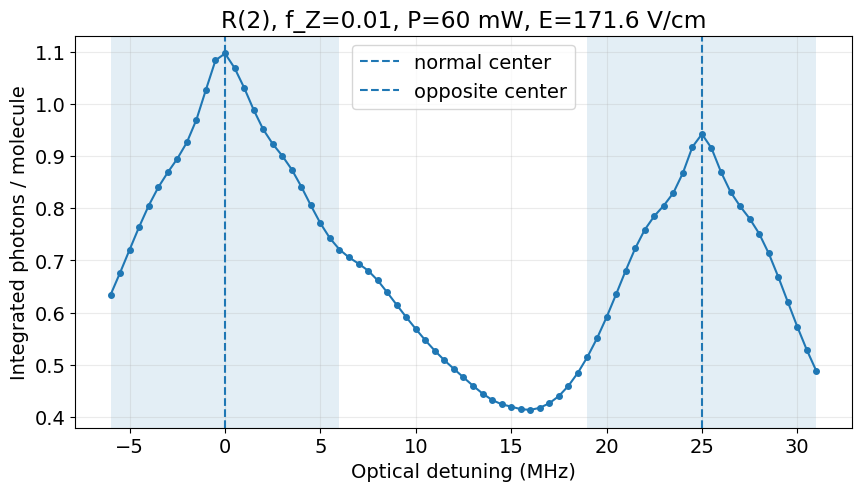

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
ax.plot(detuning_MHz, example_scan["photons"], marker="o", ms=4)
ax.axvline(normal_center, ls="--", label="normal center")
ax.axvline(opposite_center, ls="--", label="opposite center")
ax.axvspan(normal_center - PEAK_WINDOW_MHZ, normal_center + PEAK_WINDOW_MHZ, alpha=0.12)
ax.axvspan(opposite_center - PEAK_WINDOW_MHZ, opposite_center + PEAK_WINDOW_MHZ, alpha=0.12)
ax.set_xlabel("Optical detuning (MHz)")
ax.set_ylabel("Integrated photons / molecule")
ax.set_title(
    f"R(2), f_Z={example_model.z_intensity_fraction:g}, "
    f"P={POWER_MW:g} mW, E={E_FIELD_Z_V_CM:g} V/cm"
)
ax.grid(alpha=0.25)
ax.legend()

## Scan Z-polarization fraction

In [10]:
rows = []
scan_cache: dict[int, dict[str, object]] = {}

scan_start = time.perf_counter()
for z_index, fz in enumerate(Z_INTENSITY_FRACTIONS):
    model = build_model_for_z_index(z_index)

    # Energies do not change with polarization for fixed E/B, but this lets you
    # easily adapt to a future case where you vary field too.
    centers = estimate_peak_centers_from_diagonal(model)
    normal_center = centers["normal_center_MHz"]
    opposite_center = centers["opposite_center_MHz"]
    detuning_MHz = detuning_grid_for_peak_windows(normal_center, opposite_center)

    scan = photon_count_frequency_scan(model, detuning_MHz)
    scan_cache[z_index] = scan

    normal_peak = peak_height_in_window(detuning_MHz, scan["photons"], normal_center)
    opposite_peak = peak_height_in_window(detuning_MHz, scan["photons"], opposite_center)

    rows.append(
        {
            "z_index": z_index,
            "z_intensity_fraction": float(fz),
            "x_intensity_fraction": float(1 - fz),
            "E_z_over_E_x": float(np.sqrt(fz / (1 - fz))) if fz < 1 else np.inf,
            "polarization_angle_deg": float(np.degrees(np.arcsin(np.sqrt(fz)))),
            "rabi_MHz": float(scan["rabi_MHz"]),
            "normal_center_MHz": normal_center,
            "opposite_center_MHz": opposite_center,
            "normal_peak_detuning_MHz": normal_peak["peak_detuning_MHz"],
            "normal_peak_height": normal_peak["peak_height"],
            "normal_peak_edge_hit": normal_peak["edge_hit"],
            "opposite_peak_detuning_MHz": opposite_peak["peak_detuning_MHz"],
            "opposite_peak_height": opposite_peak["peak_height"],
            "opposite_peak_edge_hit": opposite_peak["edge_hit"],
            "opposite_over_normal": opposite_peak["peak_height"] / normal_peak["peak_height"],
            "normal_over_opposite": normal_peak["peak_height"] / opposite_peak["peak_height"],
        }
    )

z_scan_seconds = time.perf_counter() - scan_start
z_scan_df = pd.DataFrame(rows)

# Normalize changes to the pure-X result to make scaling obvious.
pure_x = z_scan_df.iloc[0]
z_scan_df["normal_peak_relative_to_pure_X"] = (
    z_scan_df["normal_peak_height"] / pure_x["normal_peak_height"]
)
z_scan_df["opposite_peak_relative_to_pure_X"] = (
    z_scan_df["opposite_peak_height"] / pure_x["opposite_peak_height"]
)
z_scan_df["ratio_relative_to_pure_X"] = (
    z_scan_df["opposite_over_normal"] / pure_x["opposite_over_normal"]
)

{
    "z_scan_seconds": z_scan_seconds,
    "cache_info": build_model_for_z_index.cache_info(),
    "fields_built": len(BUILD_LOG),
}

c:\Users\ogras\Documents\GitHub\CeNTREX-TlF\.venv\Lib\site-packages\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.4963147486797635, 0.4962686894496859, 0.4963147485937052, 0.4962686894587732]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
c:\Users\ogras\Documents\GitHub\CeNTREX-TlF\.venv\Lib\site-packages\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [8, 10]. Overlaps: [0.48252736332044555, 0.48252732856599473]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
c:\Users\ogras\Documents\GitHub\CeNTREX-TlF\.venv\Lib\site-packages\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.4963147486797635, 0.4962686894496859, 0.49631

{'z_scan_seconds': 199.21520410000812,
 'cache_info': CacheInfo(hits=2, misses=10, maxsize=None, currsize=10),
 'fields_built': 10}

In [11]:
z_scan_df

,z_index,z_intensity_fraction,x_intensity_fraction,E_z_over_E_x,polarization_angle_deg,rabi_MHz,normal_center_MHz,opposite_center_MHz,normal_peak_detuning_MHz,normal_peak_height,normal_peak_edge_hit,opposite_peak_detuning_MHz,opposite_peak_height,opposite_peak_edge_hit,opposite_over_normal,normal_over_opposite,normal_peak_relative_to_pure_X,opposite_peak_relative_to_pure_X,ratio_relative_to_pure_X
0,0,0.0000,1.0000,0.000000,0.000000,0.316368,8.838714e-07,24.999322,5.000009e-01,1.009879,False,25.000001,0.894102,False,0.885355,1.129490,1.000000,1.000000,1.000000
1,1,0.0001,0.9999,0.010001,0.572967,0.316352,8.838714e-07,24.999322,5.000009e-01,1.010555,False,25.000001,0.894657,False,0.885313,1.129545,1.000670,1.000621,0.999951
2,2,0.0003,0.9997,0.017323,0.992442,0.316321,8.838714e-07,24.999322,5.000009e-01,1.011901,False,25.000001,0.895762,False,0.885227,1.129654,1.002003,1.001857,0.999855
3,3,0.0010,0.9990,0.031639,1.812154,0.316210,8.838714e-07,24.999322,8.838714e-07,1.018541,False,25.000001,0.899577,False,0.883202,1.132244,1.008578,1.006124,0.997567
4,4,0.0030,0.9970,0.054855,3.139790,0.315893,8.838714e-07,24.999322,8.838714e-07,1.038530,False,25.000001,0.910039,False,0.876277,1.141192,1.028371,1.017826,0.989746
5,5,0.0100,0.9900,0.100504,5.739170,0.314782,8.838714e-07,24.999322,8.838714e-07,1.096301,False,25.000001,0.941995,False,0.859248,1.163808,1.085577,1.053566,0.970512
6,6,0.0200,0.9800,0.142857,8.130102,0.313188,8.838714e-07,24.999322,8.838714e-07,1.154530,False,25.000001,0.977183,False,0.846391,1.181487,1.143236,1.092922,0.955990
7,7,0.0500,0.9500,0.229416,12.920966,0.308358,8.838714e-07,24.999322,8.838714e-07,1.240963,False,25.000001,1.034872,False,0.833927,1.199146,1.228824,1.157443,0.941911
8,8,0.1000,0.9000,0.333333,18.434949,0.300133,8.838714e-07,24.999322,8.838714e-07,1.282729,False,25.000001,1.057408,False,0.824343,1.213087,1.270181,1.182649,0.931087
9,9,0.2000,0.8000,0.500000,26.565051,0.282968,8.838714e-07,24.999322,5.000009e-01,1.306317,False,25.000001,1.032726,False,0.790563,1.264921,1.293539,1.155044,0.892933


## Plots

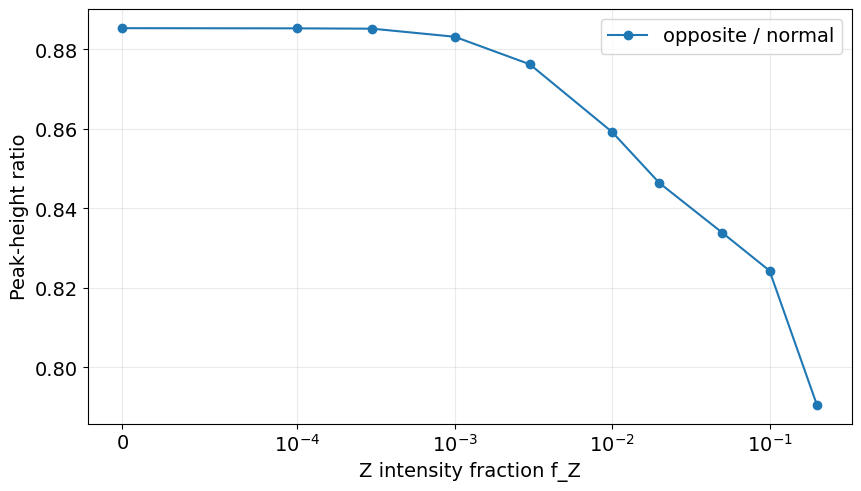

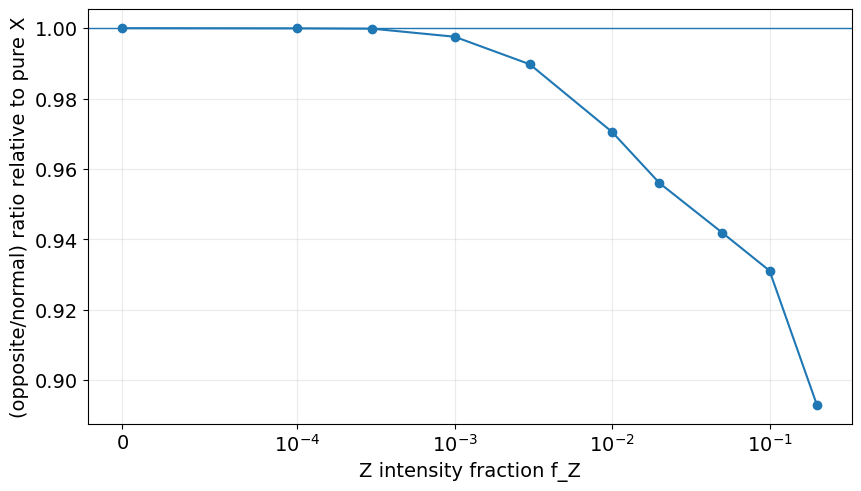

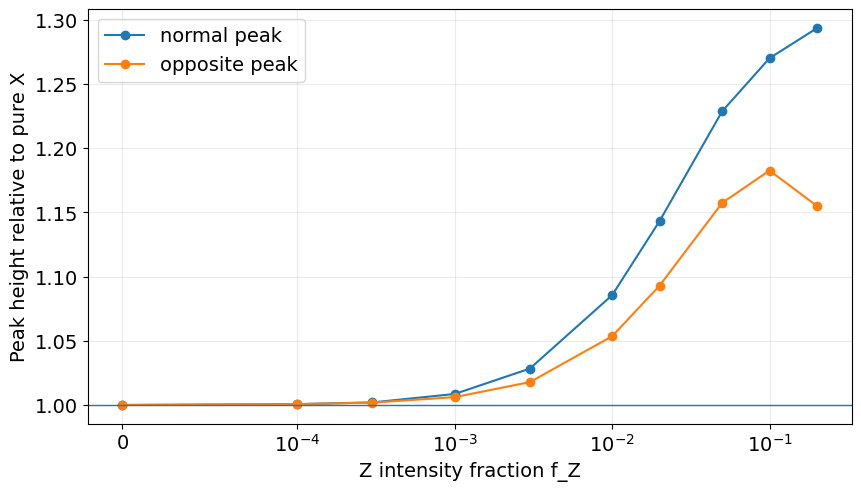

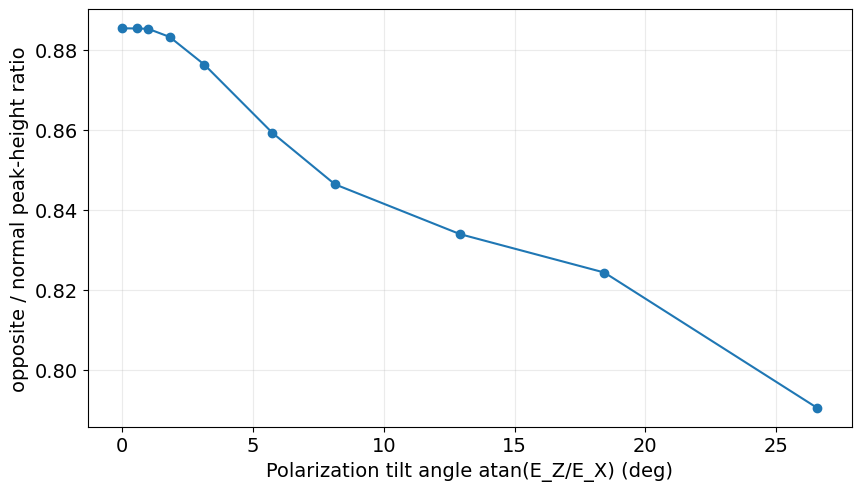

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
ax.plot(
    z_scan_df["z_intensity_fraction"],
    z_scan_df["opposite_over_normal"],
    marker="o",
    label="opposite / normal",
)
ax.set_xscale("symlog", linthresh=1e-4)
ax.set_xlabel("Z intensity fraction f_Z")
ax.set_ylabel("Peak-height ratio")
ax.grid(alpha=0.25)
ax.legend()

fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
ax.plot(
    z_scan_df["z_intensity_fraction"],
    z_scan_df["ratio_relative_to_pure_X"],
    marker="o",
)
ax.set_xscale("symlog", linthresh=1e-4)
ax.axhline(1.0, lw=1)
ax.set_xlabel("Z intensity fraction f_Z")
ax.set_ylabel("(opposite/normal) ratio relative to pure X")
ax.grid(alpha=0.25)

fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
ax.plot(
    z_scan_df["z_intensity_fraction"],
    z_scan_df["normal_peak_relative_to_pure_X"],
    marker="o",
    label="normal peak",
)
ax.plot(
    z_scan_df["z_intensity_fraction"],
    z_scan_df["opposite_peak_relative_to_pure_X"],
    marker="o",
    label="opposite peak",
)
ax.set_xscale("symlog", linthresh=1e-4)
ax.axhline(1.0, lw=1)
ax.set_xlabel("Z intensity fraction f_Z")
ax.set_ylabel("Peak height relative to pure X")
ax.grid(alpha=0.25)
ax.legend()

fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
ax.plot(
    z_scan_df["polarization_angle_deg"],
    z_scan_df["opposite_over_normal"],
    marker="o",
)
ax.set_xlabel("Polarization tilt angle atan(E_Z/E_X) (deg)")
ax.set_ylabel("opposite / normal peak-height ratio")
ax.grid(alpha=0.25)

## Overlay selected traces

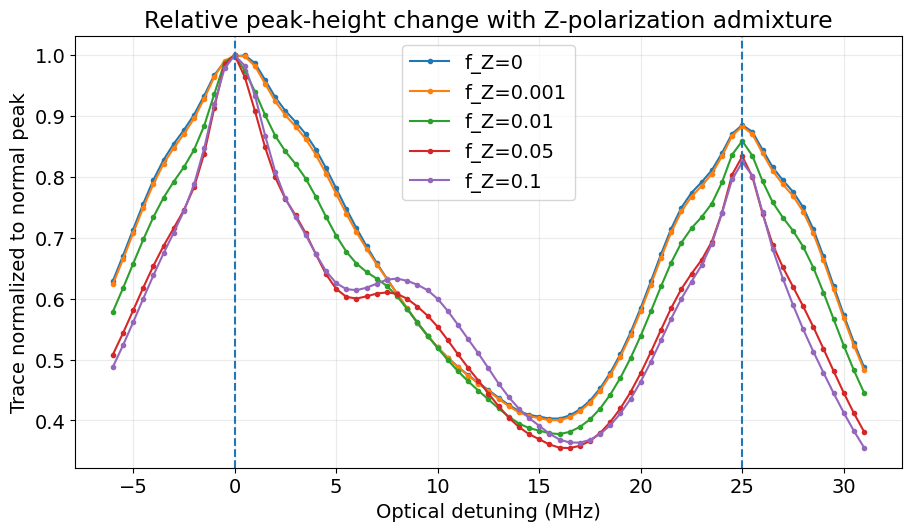

In [13]:
SELECTED_Z_FRACTIONS_FOR_TRACE_PLOT = [0.0, 1e-3, 1e-2, 5e-2, 1e-1]

fig, ax = plt.subplots(figsize=(9.0, 5.2), constrained_layout=True)

for requested_fz in SELECTED_Z_FRACTIONS_FOR_TRACE_PLOT:
    z_index = int(np.argmin(np.abs(Z_INTENSITY_FRACTIONS - requested_fz)))
    scan = scan_cache[z_index]
    photons = scan["photons"]
    # Normalize each trace to its own normal peak to emphasize relative-shape changes.
    normal_center = z_scan_df.loc[z_scan_df["z_index"] == z_index, "normal_center_MHz"].iloc[0]
    normal_peak = peak_height_in_window(scan["detuning_MHz"], photons, normal_center)
    y = photons / normal_peak["peak_height"]
    ax.plot(
        scan["detuning_MHz"],
        y,
        marker="o",
        ms=3,
        label=f"f_Z={Z_INTENSITY_FRACTIONS[z_index]:g}",
    )

ax.axvline(peak_centers["normal_center_MHz"], ls="--")
ax.axvline(peak_centers["opposite_center_MHz"], ls="--")
ax.set_xlabel("Optical detuning (MHz)")
ax.set_ylabel("Trace normalized to normal peak")
ax.set_title("Relative peak-height change with Z-polarization admixture")
ax.grid(alpha=0.25)
ax.legend()

## Optional: compare with a small power scan at fixed Z fraction

In [14]:
RUN_POWER_SCAN_AT_FIXED_Z = False

if RUN_POWER_SCAN_AT_FIXED_Z:
    FIXED_Z_INTENSITY_FRACTION = 1e-2
    POWER_SCAN_MW = np.geomspace(0.3, 100.0, 10)
    z_index = int(np.argmin(np.abs(Z_INTENSITY_FRACTIONS - FIXED_Z_INTENSITY_FRACTION)))
    model = build_model_for_z_index(z_index)

    centers = estimate_peak_centers_from_diagonal(model)
    detuning_MHz = detuning_grid_for_peak_windows(
        centers["normal_center_MHz"],
        centers["opposite_center_MHz"],
    )

    power_rows = []
    for power_mw in POWER_SCAN_MW:
        scan = photon_count_frequency_scan(model, detuning_MHz, power_w=power_mw * 1e-3)
        normal_peak = peak_height_in_window(
            detuning_MHz, scan["photons"], centers["normal_center_MHz"]
        )
        opposite_peak = peak_height_in_window(
            detuning_MHz, scan["photons"], centers["opposite_center_MHz"]
        )
        power_rows.append(
            {
                "power_mW": float(power_mw),
                "z_intensity_fraction": model.z_intensity_fraction,
                "rabi_MHz": float(scan["rabi_MHz"]),
                "normal_peak_height": normal_peak["peak_height"],
                "opposite_peak_height": opposite_peak["peak_height"],
                "opposite_over_normal": opposite_peak["peak_height"] / normal_peak["peak_height"],
            }
        )

    power_scan_df = pd.DataFrame(power_rows)
    display(power_scan_df)

    fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
    ax.semilogx(power_scan_df["power_mW"], power_scan_df["opposite_over_normal"], marker="o")
    ax.set_xlabel("Power (mW)")
    ax.set_ylabel("opposite / normal peak-height ratio")
    ax.set_title(f"Power scan at f_Z={model.z_intensity_fraction:g}")
    ax.grid(alpha=0.25)

## Interpretation notes

- This notebook keeps total optical power fixed while rotating polarization from X toward Z.
- A large change in `opposite_over_normal` with tiny `f_Z` would suggest that polarization impurity can mimic the low-power behavior seen in the fit.
- A weak change in `opposite_over_normal` would suggest that the low effective power is probably coming from another missing average: intensity distribution, shorter interaction length, field inhomogeneity, or detection/normalization effects.
- Check `normal_peak_edge_hit` and `opposite_peak_edge_hit`; if either is `True`, increase `PEAK_WINDOW_MHZ` or use a wider detuning grid.